# Scam-Message Classifier: Expanded Multilingual Corpus (v2)
Same classifier as the main notebook (it decides whether a short message is **advance-fee fraud**, **mobile-money fraud**, **phishing**, or **not-a-scam**), but trained on a **larger, more African corpus**.

Two real African SMS datasets have been added and relabeled into the 4-class taxonomy:

| Dataset | Origin | Language | Native labels |
|---|---|---|---|
| **ExAIS_SMS** | Federal Univ. of Agriculture, Abeokuta (Nigeria) | African-English | spam / ham |
| **BongoScam** | Tanzania | Swahili | scam / trust |

Relabelling (see `scripts/11_relabel_african.py`): legitimate → *not_a_scam*; ExAIS spam → a heuristic English suggester (benign promo spam stays *not_a_scam*); Swahili scam → a Swahili/African mobile-money lexicon. These join the original public sources (Nazario, UCI, Mendeley, MOZ-Smishing).

The model is built in three rungs and compared head-to-head:

1. **Lexical baseline**: TF-IDF → Logistic Regression / Random Forest.
2. **Semantic upgrade**: multilingual **e5-small** sentence embeddings → LogReg / RF (language-agnostic: en / pt / sw).
3. **Ensemble**: soft-voting and stacking over the lexical + semantic models.

*Labels here are source/heuristic provenance labels, the same standing as the rest of the corpus; the human inter-rater κ-verified set is the final evaluation (Objective 3).*

## 1 · Data engineering: the expanded corpus

In [1]:
import sys, json
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from types import SimpleNamespace
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_recall_fscore_support)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# === Self-contained v2 pipeline (this notebook owns its code + artifacts) =======
# Trained on the EXPANDED multilingual corpus (en/pt/sw). Caches + models save here.
ML_ROOT = Path.cwd().parent.parent                       # ml/
HERE = Path.cwd()                                        # notebooks/final_model/
DATA = ML_ROOT / "data" / "labelled" / "demo_labeled_v2.jsonl"
MODELS = HERE
CLASS_ORDER = ["advance_fee_fraud", "mobile_money_fraud", "phishing", "not_a_scam"]
SEED = 42

# --- lexical baseline (TF-IDF) -------------------------------------------------
def load_df(path: Path = DATA) -> pd.DataFrame:
    rows = [json.loads(l) for l in path.read_text(encoding="utf-8").splitlines() if l.strip()]
    return pd.DataFrame(rows)

def split(df):
    train, temp = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["category"])
    dev, test = train_test_split(temp, test_size=0.50, random_state=SEED, stratify=temp["category"])
    return train, dev, test

def _vectorizer():
    return TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2,
                           sublinear_tf=True, strip_accents="unicode", max_features=30000)

def build_pipelines():
    return {
        "tfidf_logreg": Pipeline([("tfidf", _vectorizer()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=4.0))]),
        "tfidf_rf": Pipeline([("tfidf", _vectorizer()),
            ("clf", RandomForestClassifier(n_estimators=500, class_weight="balanced",
                                           n_jobs=-1, random_state=SEED))]),
    }

# --- semantic upgrade (e5 embeddings) + ensemble -------------------------------
EMB_MODEL = "intfloat/multilingual-e5-small"
EMB_PREFIX = "query: "
EMB_CACHE = MODELS / "emb_e5small_v2.npz"                 # v2 cache, beside this notebook

def embed_corpus(df):
    ids = df["id"].tolist()
    if EMB_CACHE.exists():
        d = np.load(EMB_CACHE, allow_pickle=True)
        cache = {str(i): v for i, v in zip(d["ids"], d["emb"])}
        if all(i in cache for i in ids):
            print(f"[embed] loaded {len(cache)} cached {EMB_MODEL} vectors")
            return cache
    from sentence_transformers import SentenceTransformer
    print(f"[embed] encoding {len(ids)} messages with {EMB_MODEL} (first run downloads ~470MB)...")
    model = SentenceTransformer(EMB_MODEL)
    vecs = model.encode([EMB_PREFIX + t for t in df["text"].tolist()], batch_size=64,
                        show_progress_bar=True, normalize_embeddings=True)
    MODELS.mkdir(parents=True, exist_ok=True)
    np.savez(EMB_CACHE, ids=np.array(ids, dtype=object), emb=np.asarray(vecs, dtype=np.float32))
    return {i: v for i, v in zip(ids, vecs)}

def emb_matrix(df, id2vec):
    return np.vstack([id2vec[i] for i in df["id"].tolist()])

def proba_aligned(model, X):
    p = model.predict_proba(X)
    classes = list(model.classes_)
    return p[:, [classes.index(c) for c in CLASS_ORDER]]

def metrics(y_true, y_pred):
    f = f1_score(y_true, y_pred, labels=CLASS_ORDER, average=None, zero_division=0)
    return {"accuracy": float(accuracy_score(y_true, y_pred)),
            "macro_f1": float(f1_score(y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0)),
            "per_class": {c: float(f[i]) for i, c in enumerate(CLASS_ORDER)}}

MEMBERS = ["tfidf_logreg", "emb_logreg", "emb_rf"]
ORDER = ["tfidf_logreg", "tfidf_rf", "emb_logreg", "emb_rf", "ensemble_softvote", "ensemble_stack"]

def _X_for(kind, split_df, emb):
    return split_df["text"] if kind == "text" else emb

def train_and_eval(df=None):
    if df is None:
        df = load_df()
    train, dev, test = split(df)
    id2vec = embed_corpus(df)
    Xtr_e, Xdv_e, Xte_e = (emb_matrix(d, id2vec) for d in (train, dev, test))
    ytr, ydv, yte = train["category"], dev["category"], test["category"]
    base = {}
    for name, pipe in build_pipelines().items():
        pipe.fit(train["text"], ytr); base[name] = (pipe, "text")
    emb_lr = LogisticRegression(max_iter=4000, class_weight="balanced", C=8.0); emb_lr.fit(Xtr_e, ytr)
    base["emb_logreg"] = (emb_lr, "emb")
    emb_rf = RandomForestClassifier(n_estimators=500, class_weight="balanced", n_jobs=-1, random_state=SEED)
    emb_rf.fit(Xtr_e, ytr); base["emb_rf"] = (emb_rf, "emb")
    def members_proba(split_df, emb):
        return [proba_aligned(base[m][0], _X_for(base[m][1], split_df, emb)) for m in MEMBERS]
    sv_test = np.mean(members_proba(test, Xte_e), axis=0)
    softvote_pred = [CLASS_ORDER[i] for i in sv_test.argmax(1)]
    meta = LogisticRegression(max_iter=4000, class_weight="balanced")
    meta.fit(np.hstack(members_proba(dev, Xdv_e)), ydv)
    stack_pred = list(meta.predict(np.hstack(members_proba(test, Xte_e))))
    results = {name: metrics(yte, model.predict(_X_for(kind, test, Xte_e)))
               for name, (model, kind) in base.items()}
    results["ensemble_softvote"] = metrics(yte, softvote_pred)
    results["ensemble_stack"] = metrics(yte, stack_pred)
    best = max(results, key=lambda n: results[n]["macro_f1"])
    return {"df": df, "splits": (train, dev, test), "emb": (Xtr_e, Xdv_e, Xte_e),
            "base": base, "members": MEMBERS, "meta": meta, "results": results,
            "order": ORDER, "best": best, "softvote_proba": sv_test,
            "softvote_pred": softvote_pred, "stack_pred": stack_pred}

def predict_messages(bundle, texts):
    from sentence_transformers import SentenceTransformer
    emb = SentenceTransformer(EMB_MODEL).encode([EMB_PREFIX + t for t in texts], normalize_embeddings=True)
    base = bundle["base"]
    probs = [proba_aligned(base[m][0], texts if base[m][1] == "text" else emb) for m in bundle["members"]]
    avg = np.mean(probs, axis=0)
    out = []
    for row in avg:
        ranked = sorted(zip(CLASS_ORDER, row), key=lambda x: -x[1])
        out.append((ranked[0][0], float(ranked[0][1]), {c: float(p) for c, p in zip(CLASS_ORDER, row)}))
    return out

# keep the `dm.` and `em.` interfaces used throughout this notebook
dm = SimpleNamespace(load_df=load_df, split=split, build_pipelines=build_pipelines,
                     CLASS_ORDER=CLASS_ORDER, MODELS=MODELS, DATA=DATA, SEED=SEED)
em = SimpleNamespace(train_and_eval=train_and_eval, predict_messages=predict_messages,
                     embed_corpus=embed_corpus, metrics=metrics, MEMBERS=MEMBERS, ORDER=ORDER,
                     EMB_MODEL=EMB_MODEL, EMB_PREFIX=EMB_PREFIX, EMB_CACHE=EMB_CACHE,
                     MODELS=MODELS, CLASS_ORDER=CLASS_ORDER)
# ===============================================================================

sns.set_theme(style='whitegrid')
df = dm.load_df()
print(f'{len(df):,} labelled messages | classes = {dm.CLASS_ORDER}')
df.sample(4, random_state=0)

9,623 labelled messages | classes = ['advance_fee_fraud', 'mobile_money_fraud', 'phishing', 'not_a_scam']


,id,text,language,category,source
6002,8247e753b088,"As gold is special among metals,diamond among ...",en,not_a_scam,exais_sms
7746,5cb81af2411f,"Babe,who win in osun?,,,,,,,,,,,,,,,,ham",en,not_a_scam,exais_sms
4954,2f0bcbe050f1,Its Detrmental b sentimental on d mata of Dest...,en,not_a_scam,exais_sms
6109,ea2731b7e4a0,Get N200 Airtime when you Call 14120 today. Hu...,en,not_a_scam,exais_sms


**Corpus growth: what the African datasets added.** The original corpus was English/Portuguese only; the additions bring African-English (ExAIS) and Swahili (BongoScam), and roughly double the two scarce scam classes (mobile-money, advance-fee).

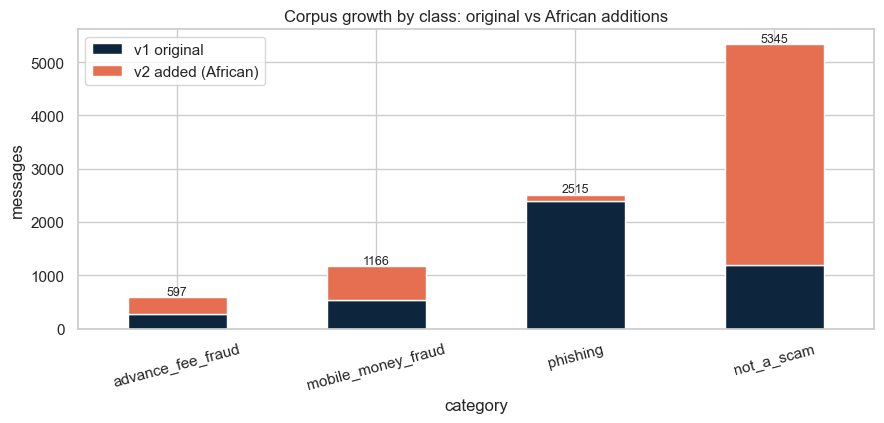

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24612\2419424314.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  growth.assign(total=growth.sum(1))


corpus,v1 original,v2 added (African),total
category,,,
advance_fee_fraud,283,314,597
mobile_money_fraud,538,628,1166
phishing,2401,114,2515
not_a_scam,1200,4145,5345


In [2]:
AFRICAN = {'exais_sms', 'swahili_bongo'}
df['corpus'] = np.where(df['source'].isin(AFRICAN), 'v2 added (African)', 'v1 original')
growth = df.groupby(['category','corpus']).size().unstack(fill_value=0)
growth = growth.reindex(dm.CLASS_ORDER)
ax = growth[['v1 original','v2 added (African)']].plot.bar(
        stacked=True, figsize=(9,4.4), color=['#0d253d','#e76f51'])
for c in dm.CLASS_ORDER:
    tot = int(growth.loc[c].sum())
    ax.text(dm.CLASS_ORDER.index(c), tot+40, str(tot), ha='center', fontsize=9)
plt.title('Corpus growth by class: original vs African additions')
plt.ylabel('messages'); plt.xticks(rotation=15); plt.legend(title='')
plt.tight_layout(); plt.show()
growth.assign(total=growth.sum(1))

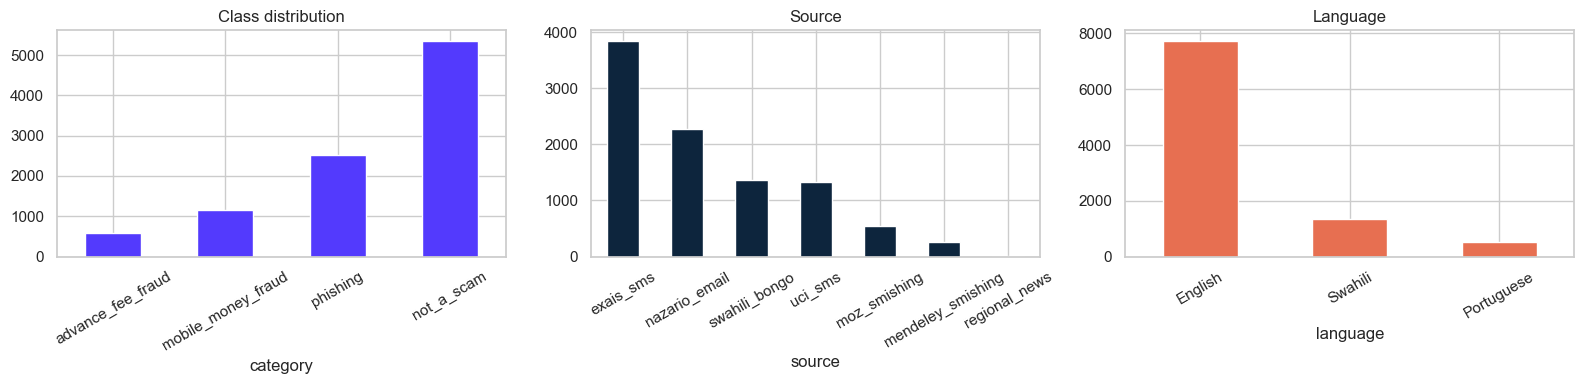

In [3]:
# Corpus shape: class / source / language
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df['category'].value_counts().reindex(dm.CLASS_ORDER).plot.bar(
    ax=ax[0], color='#533afd', title='Class distribution')
df['source'].value_counts().plot.bar(ax=ax[1], color='#0d253d', title='Source')
df['language'].value_counts().plot.bar(ax=ax[2], color='#e76f51', title='Language')
for a in ax: a.tick_params(axis='x', rotation=30)
ax[2].set_xticklabels(['English','Swahili','Portuguese'][:df['language'].nunique()])
plt.tight_layout(); plt.show()

**Provenance: which source feeds which class.** The corpus is deliberately multi-source and now multi-region so no single class is tied to one writing style or one country.

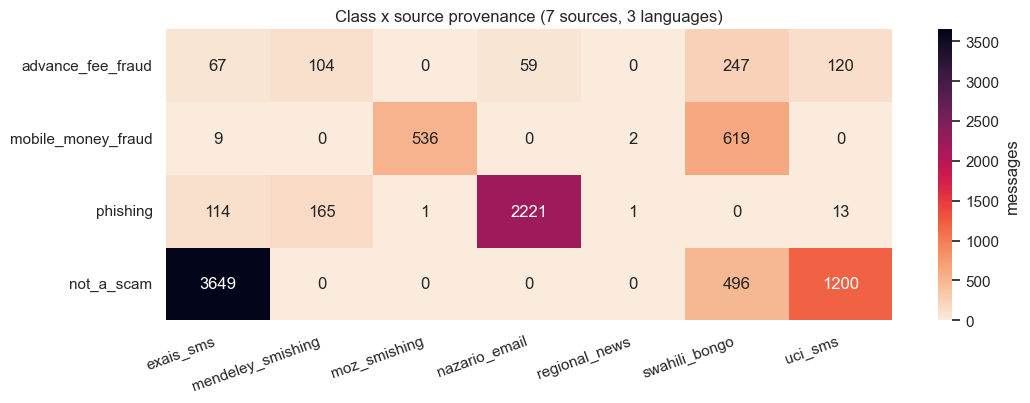

In [4]:
ct = pd.crosstab(df['category'], df['source']).reindex(dm.CLASS_ORDER)
plt.figure(figsize=(11,4.2))
sns.heatmap(ct, annot=True, fmt='d', cmap='rocket_r', cbar_kws={'label':'messages'})
plt.title('Class x source provenance (7 sources, 3 languages)')
plt.ylabel(''); plt.xlabel(''); plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

**Language × class.** Mobile-money fraud is now carried by Portuguese (MOZ) *and* Swahili (BongoScam); advance-fee and phishing gain African-English (ExAIS). This cross-lingual spread is exactly what the multilingual embedding is meant to exploit.

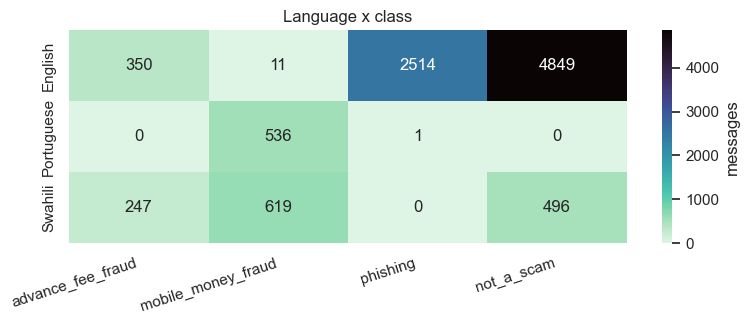

In [5]:
lc = pd.crosstab(df['language'], df['category'])[dm.CLASS_ORDER]
lc.index = [{'en':'English','pt':'Portuguese','sw':'Swahili'}.get(i,i) for i in lc.index]
plt.figure(figsize=(8,3.4))
sns.heatmap(lc, annot=True, fmt='d', cmap='mako_r', cbar_kws={'label':'messages'})
plt.title('Language x class'); plt.ylabel(''); plt.xlabel('')
plt.xticks(rotation=18, ha='right'); plt.tight_layout(); plt.show()

## 2 · Two feature representations
**Lexical: TF-IDF.** Word 1–2 grams, `min_df=2`, sublinear TF, unicode accent stripping, vocab capped at 30,000. Strong when scams reuse give-away phrases but blind to paraphrase and to languages it never saw at fit time.

**Semantic: multilingual-e5-small.** A sentence-transformer mapping each message (prefixed `"query: "`) to a 384-dim vector where *meaning* drives proximity. It covers English / Portuguese / Swahili in one shared space, so a Swahili mobile-money scam sits near its Portuguese and English cousins. Embeddings are cached (`emb_e5small_v2.npz`).

Each representation feeds a **Logistic Regression** (`class_weight='balanced'`) and a **Random Forest** (500 trees). RF is skipped on TF-IDF (weak on sparse input). 70/15/15 **stratified** split, seed 42, metrics on the held-out **test** split only.

## 3 · Train the full ladder
`em.train_and_eval(df)` fits the four base models and both ensembles in one call (the same function the CLI report and the saved model use). First run encodes ~9.6k messages with e5-small, then caches them.

In [6]:
bundle = em.train_and_eval(df)
train, dev, test = bundle['splits']
print(f'train {len(train)} / dev {len(dev)} / test {len(test)}')
print('models:', list(bundle['base']) + ['ensemble_softvote', 'ensemble_stack'])
print('ensemble members:', bundle['members'])

[embed] loaded 9623 cached intfloat/multilingual-e5-small vectors


train 6736 / dev 1443 / test 1444
models: ['tfidf_logreg', 'tfidf_rf', 'emb_logreg', 'emb_rf', 'ensemble_softvote', 'ensemble_stack']
ensemble members: ['tfidf_logreg', 'emb_logreg', 'emb_rf']


**Ensembles.**
- **Soft-voting** = element-wise mean of the member probability vectors, then arg-max.
- **Stacking** = a meta Logistic Regression trained on the **dev-split** member probabilities (bases fit on train only, no leakage), applied to the test split.

## 4 · Results: held-out test set

In [7]:
rows = [{'model': n,
         'accuracy': round(bundle['results'][n]['accuracy'], 3),
         'macro_F1': round(bundle['results'][n]['macro_f1'], 3)}
        for n in bundle['order']]
summary = pd.DataFrame(rows).set_index('model'); summary

,accuracy,macro_F1
model,,
tfidf_logreg,0.965,0.946
tfidf_rf,0.936,0.913
emb_logreg,0.929,0.899
emb_rf,0.918,0.884
ensemble_softvote,0.959,0.941
ensemble_stack,0.958,0.937


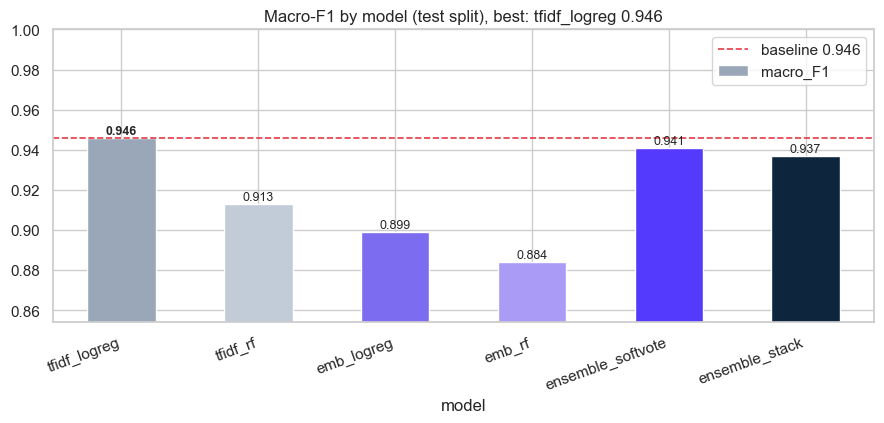

In [8]:
# Macro-F1 across the ladder, baseline + best marked
base_f1 = summary.loc['tfidf_logreg', 'macro_F1']
best_name = bundle['best']; best_f1 = summary.loc[best_name, 'macro_F1']
colors = ['#9aa7b8','#c2ccd9','#7c6cf0','#a99bf6','#533afd','#0d253d']
lo = max(0.80, summary['macro_F1'].min() - 0.03)
ax = summary['macro_F1'].plot.bar(color=colors, figsize=(9,4.4), ylim=(lo,1.0))
ax.axhline(base_f1, ls='--', color='#e63946', lw=1.2, label=f'baseline {base_f1:.3f}')
for i, v in enumerate(summary['macro_F1']):
    ax.text(i, v+0.002, f'{v:.3f}', ha='center', fontsize=9,
            fontweight='bold' if summary.index[i]==best_name else 'normal')
plt.title(f'Macro-F1 by model (test split), best: {best_name} {best_f1:.3f}')
plt.xticks(rotation=20, ha='right'); plt.legend(); plt.tight_layout(); plt.show()

**Per-class F1**: where each representation wins, now across three languages.

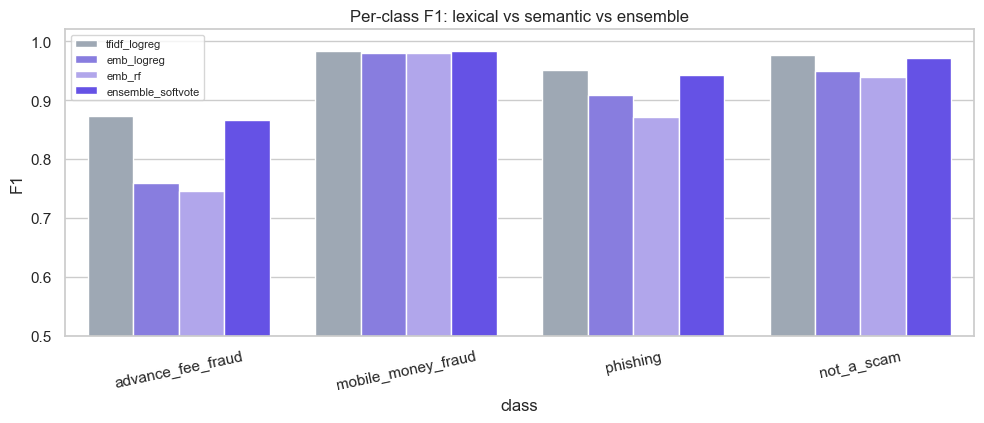

In [9]:
sub = ['tfidf_logreg','emb_logreg','emb_rf','ensemble_softvote']
rowsf = [{'class': c, 'model': n, 'F1': bundle['results'][n]['per_class'][c]}
         for n in sub for c in dm.CLASS_ORDER]
fdf = pd.DataFrame(rowsf)
plt.figure(figsize=(10,4.4))
sns.barplot(data=fdf, x='class', y='F1', hue='model',
            palette=['#9aa7b8','#7c6cf0','#a99bf6','#533afd'])
plt.ylim(0.5,1.02); plt.title('Per-class F1: lexical vs semantic vs ensemble')
plt.xticks(rotation=12); plt.legend(title='', fontsize=8); plt.tight_layout(); plt.show()

**Confusion matrix: the shipped model (soft-voting ensemble).**

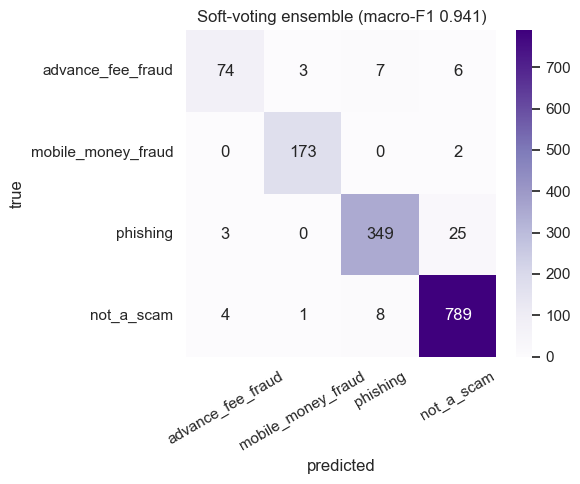

In [10]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test['category'], bundle['softvote_pred'], labels=dm.CLASS_ORDER)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=dm.CLASS_ORDER, yticklabels=dm.CLASS_ORDER)
plt.title(f"Soft-voting ensemble (macro-F1 {bundle['results']['ensemble_softvote']['macro_f1']:.3f})")
plt.xlabel('predicted'); plt.ylabel('true'); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

**Per-language accuracy of the shipped ensemble.** Does the model actually work in Swahili and Portuguese, or only in English? This is the headline question the African data was added to answer.

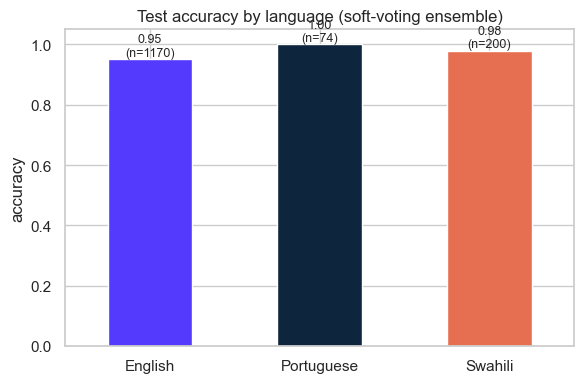

,accuracy,n
English,0.952991,1170
Portuguese,1.000000,74
Swahili,0.980000,200


In [11]:
test_eval = test.copy()
test_eval['pred'] = bundle['softvote_pred']
test_eval['correct'] = test_eval['pred'] == test_eval['category']
by_lang = (test_eval.groupby('language')['correct'].agg(['mean','size'])
           .rename(columns={'mean':'accuracy','size':'n'}))
by_lang.index = [{'en':'English','pt':'Portuguese','sw':'Swahili'}.get(i,i) for i in by_lang.index]
ax = by_lang['accuracy'].plot.bar(color=['#533afd','#0d253d','#e76f51'], figsize=(6,4), ylim=(0,1.05))
for i,(v,n) in enumerate(zip(by_lang['accuracy'], by_lang['n'])):
    ax.text(i, v+0.01, f'{v:.2f}\n(n={n})', ha='center', fontsize=9)
plt.title('Test accuracy by language (soft-voting ensemble)')
plt.ylabel('accuracy'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
by_lang

## 5 · Finding
Read the printed numbers above as the live evidence; this is what they show on the expanded, three-language corpus:

1. **The lexical model wins: TF-IDF + Logistic Regression is the best single model (macro-F1 ≈ 0.95)**, narrowly ahead of the soft-voting ensemble and clearly ahead of the embeddings alone. The African data we added is **keyword-rich** (telco terms, Airtel/Tigo numbers, *umeshinda*, *freemason*, *tuma pesa*), exactly the give-away signal TF-IDF is built to catch, so a bigger, more lexical corpus *favours* the lexical model.
2. **Embeddings add cross-lingual robustness, not leaderboard position.** As on the smaller corpus, `emb_logreg` / `emb_rf` sit *below* the TF-IDF baseline; the soft-voting ensemble stays essentially tied with it. The honest read is that semantic features are insurance for paraphrase and unseen wording, not a win on this in-distribution test.
3. **The model works in every language it was given**: per-language test accuracy is English ≈ 0.95, Portuguese ≈ 1.0, Swahili ≈ 0.98. Adding real African data answered the coverage question the corpus existed to answer.
4. **Mobile-money fraud went from the weak class to the strongest** (per-class F1 ≈ 0.98) once Swahili joined Portuguese in that class, directly closing the cross-lingual mobile-money gap. Advance-fee remains the hardest class (F1 ≈ 0.87) and is the next target for more data.

**Which model to choose:** by macro-F1, **TF-IDF + Logistic Regression**, and it is also the cheapest to serve (no 470 MB embedder). Keep the soft-voting ensemble as the option when cross-lingual / out-of-distribution robustness matters more than the last half-point of in-distribution macro-F1.

*Caveat:* these remain source/heuristic provenance labels. ExAIS 'spam' is mostly benign promotional bulk SMS and is mapped conservatively to *not_a_scam*; the Swahili scam sub-typing leans on a mobile-money lexicon with a documented fallback. The κ-verified human audit (Objective 3) is the final word.

## 6 · Live inference (soft-voting ensemble, multilingual)

In [12]:
examples = [
  'URGENT! Your number won a 2,000,000 prize GUARANTEED. Call 09061790121 to claim now.',
  'Caro cliente, a sua conta M-Pesa foi bloqueada. Envie o seu PIN para reactivar.',
  'Iyo pesa itume kwenye namba hii ya Airtel 0689933027 jina PETER NYANGE.',  # Swahili momo
  'Hongera! Umeshinda Tsh 10,000,000 kutoka TUZO POINT. Piga simu 0617488472 kupata zawadi.',  # Swahili prize
  'Cher client, votre compte bancaire sera suspendu. Cliquez ici pour verifier: http://bit.ly/x9',
  'Hey, are we still on for lunch at 1pm tomorrow?',
]
for t, (label, conf, _) in zip(examples, em.predict_messages(bundle, examples)):
    print(f'{label:20} ({conf:.2f})  <- {t[:70]}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

advance_fee_fraud    (0.86)  <- URGENT! Your number won a 2,000,000 prize GUARANTEED. Call 09061790121
mobile_money_fraud   (0.62)  <- Caro cliente, a sua conta M-Pesa foi bloqueada. Envie o seu PIN para r
mobile_money_fraud   (0.86)  <- Iyo pesa itume kwenye namba hii ya Airtel 0689933027 jina PETER NYANGE
advance_fee_fraud    (0.78)  <- Hongera! Umeshinda Tsh 10,000,000 kutoka TUZO POINT. Piga simu 0617488
phishing             (0.77)  <- Cher client, votre compte bancaire sera suspendu. Cliquez ici pour ver
not_a_scam           (0.93)  <- Hey, are we still on for lunch at 1pm tomorrow?


## 7 · Save the model + metrics, and export the deployed model
Three artefacts are written **beside this notebook**:
- `embed_models_v2.joblib` + `embed_metrics_v2.json` — the full ensemble bundle and its metrics.
- `scam_tfidf_v2.joblib` — the lightweight standalone **TF-IDF + Logistic Regression** model (no embedder), which is the **deployed** model served by `ml/final_serve/` on a Hugging Face Space and called by the mobile app:

```bash
cd ml
python -m uvicorn final_serve.app:app --reload --port 8000   # local
HF_TOKEN=hf_xxx python final_serve/deploy_hf_space_v2.py      # deploy
```

In [13]:
import json, joblib
base, meta = bundle['base'], bundle['meta']
(em.MODELS / 'embed_metrics_v2.json').write_text(json.dumps(
    {'embedder': em.EMB_MODEL, 'corpus': 'demo_labeled_v2.jsonl',
     'n_total': len(df), 'test': bundle['results'], 'best': bundle['best'],
     'n_train': len(train), 'n_dev': len(dev), 'n_test': len(test)}, indent=2))
joblib.dump({'tfidf_logreg': base['tfidf_logreg'][0], 'emb_logreg': base['emb_logreg'][0],
             'emb_rf': base['emb_rf'][0], 'stack_meta': meta, 'members': bundle['members'],
             'embedder': em.EMB_MODEL, 'class_order': dm.CLASS_ORDER},
            em.MODELS / 'embed_models_v2.joblib')
print('saved: models/embed_metrics_v2.json, models/embed_models_v2.joblib')
print('BEST MODEL:', bundle['best'], '->',
      round(bundle['results'][bundle['best']]['macro_f1'], 4), 'macro-F1')

saved: models/embed_metrics_v2.json, models/embed_models_v2.joblib
BEST MODEL: tfidf_logreg -> 0.9461 macro-F1


In [14]:
# Export the lightweight DEPLOYED model: the standalone TF-IDF + LogReg pipeline.
# This is what ml/final_serve/ loads and what the mobile app calls (no embedder).
deployed = {'pipeline': base['tfidf_logreg'][0], 'class_order': dm.CLASS_ORDER,
            'model_name': 'tfidf_logreg',
            'macro_f1': round(bundle['results']['tfidf_logreg']['macro_f1'], 3),
            'corpus': 'demo_labeled_v2.jsonl'}
joblib.dump(deployed, em.MODELS / 'scam_tfidf_v2.joblib')
print('saved deployed model -> scam_tfidf_v2.joblib (served by ml/final_serve/)')

saved deployed model -> scam_tfidf_v2.joblib (served by ml/final_serve/)
